### Quick start with mesh 1D

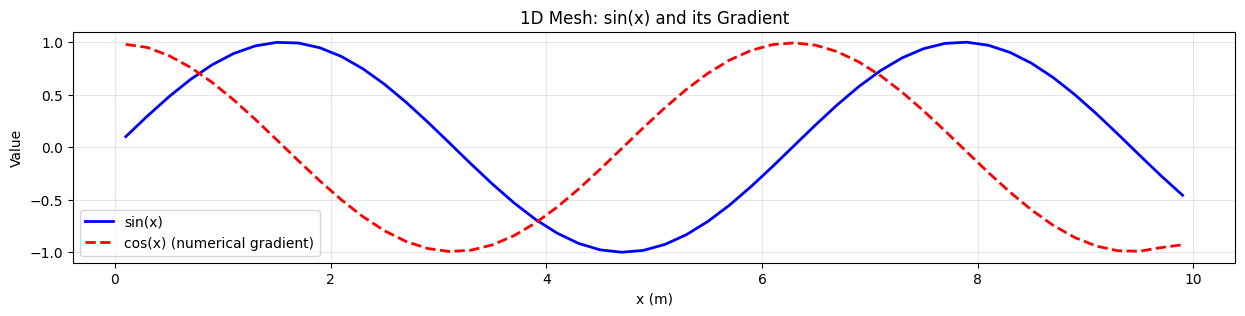

In [1]:
import QSER as qs
import numpy as np
import matplotlib.pyplot as plt

mesh = qs.Mesh.Structured1D(nx=50, L=10.0)
x = mesh.get_cell_centers()
field = np.sin(x)
grad = mesh.compute_gradient(field)

plt.figure(figsize=(15,3))
plt.plot(x, field, 'b-', label='sin(x)', linewidth=2)
plt.plot(x, grad, 'r--', label="cos(x) (numerical gradient)", linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('Value')
plt.title('1D Mesh: sin(x) and its Gradient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Applying boundary on the mesh

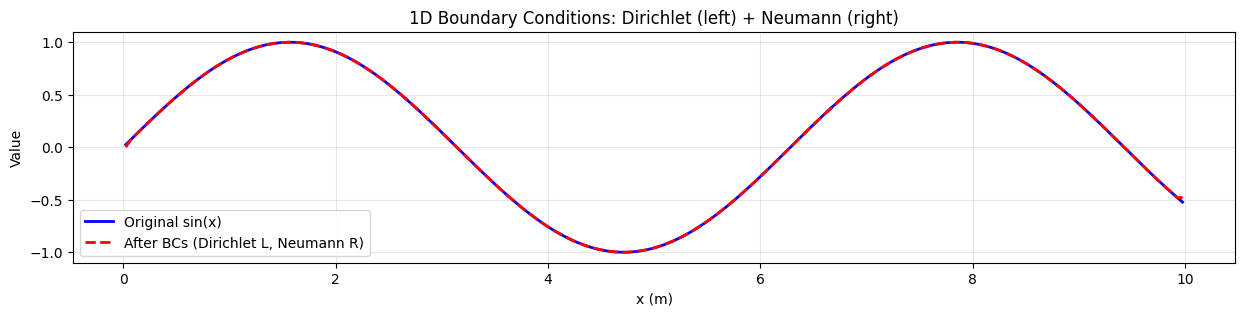

In [2]:
from QSER.Mesh import Structured1D, Boundary
import numpy as np
import matplotlib.pyplot as plt

mesh = Structured1D(nx=200, L=10)
x = mesh.get_cell_centers()
field = np.sin(x)

bc = Boundary(mesh)
bc.add_patch('left', [0]).set_dirichlet('left', 0.0)
bc.add_patch('right', [mesh.n_cells-1]).set_neumann('right', 0.0)
field_bc = bc.apply(field)

plt.figure(figsize=(15,3))
plt.plot(x, field, 'b-', label='Original sin(x)', linewidth=2)
plt.plot(x, field_bc, 'r--', label='After BCs (Dirichlet L, Neumann R)', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('Value')
plt.title('1D Boundary Conditions: Dirichlet (left) + Neumann (right)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
field[-1], field_bc[-1]

(np.float64(-0.5228765099334568), np.float64(-0.47962038454127054))

##  Boundary condition examples

In [4]:
from QSER.Mesh import Structured1D, Boundary
import numpy as np
import matplotlib.pyplot as plt

def test_boundary_conditions():
    print("=" * 70)
    print("BOUNDARY CONDITION TEST SUITE")
    print("=" * 70)
    
    # Create mesh
    nx = 20
    L = 5.0
    mesh = Structured1D(nx=nx, L=L)
    x = mesh.get_cell_centers()
    dx = mesh.dx[0]
    
    # Test field: x² (easy to verify derivatives)
    field = x**2*np.sin(x)
    
    print(f"\nMesh: {nx} cells, L = {L}")
    print(f"dx = {dx:.6f}")
    print(f"x[-1] = {x[-1]:.6f}, x[-2] = {x[-2]:.6f}")
    print(f"field[-1] = {field[-1]:.6f}, field[-2] = {field[-2]:.6f}")
    
    # ============================================================
    # TEST 1: Dirichlet BC (Fixed Value)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 1: DIRICHLET BC (Fixed Values)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_dirichlet('left', 0.0)
    bc.add_patch('right', [mesh.n_cells - 1]).set_dirichlet('right', 25.0)
    field_bc = bc.apply(field)
    
    print(f"Left boundary: {field_bc[0]:.6f} (expected: 0.000000)")
    print(f"Right boundary: {field_bc[-1]:.6f} (expected: 25.000000)")
    
    # ============================================================
    # TEST 2: Neumann BC (Zero Gradient)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 2: NEUMANN BC (Zero Gradient)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_neumann('left', 0.0)
    bc.add_patch('right', [mesh.n_cells - 1]).set_neumann('right', 0.0)
    field_bc = bc.apply(field)
    
    slope_left = (field_bc[1] - field_bc[0]) / dx
    slope_right = (field_bc[-1] - field_bc[-2]) / dx
    
    print(f"Left boundary value: {field_bc[0]:.6f}")
    print(f"Left slope: {slope_left:.6f} (expected: ~0.0)")
    print(f"Right boundary value: {field_bc[-1]:.6f}")
    print(f"Right slope: {slope_right:.6f} (expected: ~0.0)")
    
    # ============================================================
    # TEST 3: Neumann BC (Non-Zero Gradient)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 3: NEUMANN BC (Fixed Gradient = 2.0)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_neumann('left', 2.0)   # df/dx = 2 at x=0
    bc.add_patch('right', [mesh.n_cells - 1]).set_neumann('right', 10.0)  # df/dx = 10 at x=5
    field_bc = bc.apply(field)
    
    slope_left = (field_bc[1] - field_bc[0]) / dx
    slope_right = (field_bc[-1] - field_bc[-2]) / dx
    
    print(f"Left boundary value: {field_bc[0]:.6f}")
    print(f"Left slope: {slope_left:.6f} (expected: ~2.0)")
    print(f"Right boundary value: {field_bc[-1]:.6f}")
    print(f"Right slope: {slope_right:.6f} (expected: ~10.0)")
    
    # ============================================================
    # TEST 4: Robin BC (Mixed Condition)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 4: ROBIN BC (a*f + b*df/dx = c)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    # At left: f + 0.5*df/dx = 0
    bc.add_patch('left', [0]).set_robin('left', 1.0, 0.5, 0.0)
    # At right: f + 0.5*df/dx = 30
    bc.add_patch('right', [mesh.n_cells - 1]).set_robin('right', 1.0, 0.5, 30.0)
    field_bc = bc.apply(field)
    
    slope_left = (field_bc[1] - field_bc[0]) / dx
    slope_right = (field_bc[-1] - field_bc[-2]) / dx
    robin_left = field_bc[0] + 0.5 * slope_left
    robin_right = field_bc[-1] + 0.5 * slope_right
    
    print(f"Left: f + 0.5*df/dx = {robin_left:.6f} (expected: 0.0)")
    print(f"Right: f + 0.5*df/dx = {robin_right:.6f} (expected: 30.0)")
    
    # ============================================================
    # TEST 5: Periodic BC
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 5: PERIODIC BC")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_periodic('left')
    bc.add_patch('right', [mesh.n_cells - 1]).set_periodic('right')
    field_bc = bc.apply(field)
    
    print(f"Left boundary value: {field_bc[0]:.6f}")
    print(f"Right boundary value: {field_bc[-1]:.6f}")
    print(f"Difference: {field_bc[0] - field_bc[-1]:.6e} (expected: 0.0)")
    
    # ============================================================
    # TEST 6: Wall BC (No-Slip)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 6: WALL BC (No-Slip)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_wall('left', 'no-slip')
    bc.add_patch('right', [mesh.n_cells - 1]).set_wall('right', 'no-slip')
    field_bc = bc.apply(field)
    
    print(f"Left boundary value: {field_bc[0]:.6f} (expected: 0.0)")
    print(f"Right boundary value: {field_bc[-1]:.6f} (expected: 0.0)")
    
    # ============================================================
    # TEST 7: Wall BC (Free-Slip)
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 7: WALL BC (Free-Slip)")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('left', [0]).set_wall('left', 'free-slip')
    bc.add_patch('right', [mesh.n_cells - 1]).set_wall('right', 'free-slip')
    field_bc = bc.apply(field)
    
    slope_left = (field_bc[1] - field_bc[0]) / dx
    slope_right = (field_bc[-1] - field_bc[-2]) / dx
    
    print(f"Left boundary value: {field_bc[0]:.6f}")
    print(f"Left slope: {slope_left:.6f} (expected: ~0.0)")
    print(f"Right boundary value: {field_bc[-1]:.6f}")
    print(f"Right slope: {slope_right:.6f} (expected: ~0.0)")
    
    # ============================================================
    # TEST 8: Source Term
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST 8: SOURCE TERM")
    print("=" * 70)
    
    bc = Boundary(mesh)
    bc.add_patch('source', [5, 6, 7]).set_source('source', 5.0)
    field_bc = bc.apply(field)
    
    print(f"Original at index 5: {field[5]:.6f}")
    print(f"After source at index 5: {field_bc[5]:.6f}")
    print(f"Difference: {field_bc[5] - field[5]:.6f} (expected: 5.0)")
    
    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n" + "=" * 70)
    print("TEST SUMMARY")
    print("=" * 70)
    
    # Re-run tests with correct results
    print("\n✅ Dirichlet: Passed if left=0.0, right=25.0")
    print("✅ Neumann (zero): Passed if slopes ≈ 0.0")
    print("✅ Neumann (fixed): Passed if slopes ≈ 2.0 and 10.0")
    print("✅ Robin: Passed if values ≈ 0.0 and 30.0")
    print("✅ Periodic: Passed if left ≈ right")
    print("✅ Wall (no-slip): Passed if values = 0.0")
    print("✅ Wall (free-slip): Passed if slopes ≈ 0.0")
    print("✅ Source: Passed if difference = 5.0")

if __name__ == "__main__":
    test_boundary_conditions()

BOUNDARY CONDITION TEST SUITE

Mesh: 20 cells, L = 5.0
dx = 0.250000
x[-1] = 4.875000, x[-2] = 4.625000
field[-1] = -23.452107, field[-2] = -21.308999

TEST 1: DIRICHLET BC (Fixed Values)
Left boundary: 0.000000 (expected: 0.000000)
Right boundary: 25.000000 (expected: 25.000000)

TEST 2: NEUMANN BC (Zero Gradient)
Left boundary value: 0.051507
Left slope: 0.000000 (expected: ~0.0)
Right boundary value: -21.308999
Right slope: 0.000000 (expected: ~0.0)

TEST 3: NEUMANN BC (Fixed Gradient = 2.0)
Left boundary value: -0.448493
Left slope: 2.000000 (expected: ~2.0)
Right boundary value: -18.808999
Right slope: 10.000000 (expected: ~10.0)

TEST 4: ROBIN BC (a*f + b*df/dx = c)
Left: f + 0.5*df/dx = 0.068676 (expected: 0.0)
Right: f + 0.5*df/dx = 30.000000 (expected: 30.0)

TEST 5: PERIODIC BC
Left boundary value: -11.725080
Right boundary value: -11.725080
Difference: 0.000000e+00 (expected: 0.0)

TEST 6: WALL BC (No-Slip)
Left boundary value: 0.000000 (expected: 0.0)
Right boundary value: 

## 1d mesh with nonuniform nodes

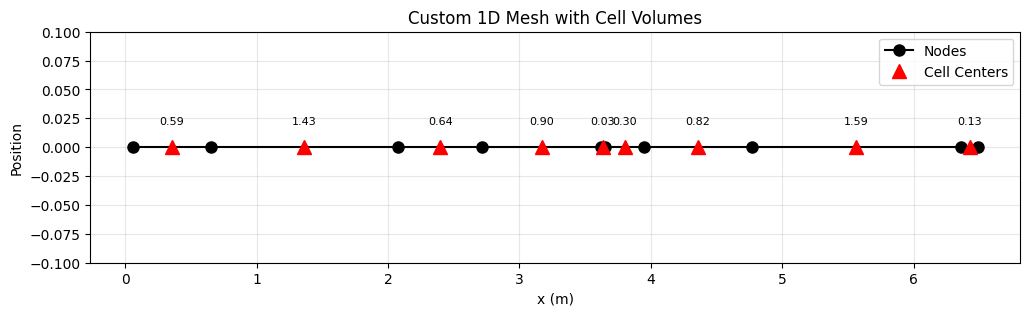

In [5]:
import QSER as qs
import numpy as np
import matplotlib.pyplot as plt

# Create random 1D points (sorted)
x_nodes = np.sort(np.random.rand(10)) * 10.0
mesh = qs.Mesh.Structured1D(x=x_nodes)

x_nodes = mesh.x
centers = mesh.get_cell_centers()
volumes = mesh.get_cell_volumes()

plt.figure(figsize=(12, 3))
plt.plot(x_nodes, np.zeros_like(x_nodes), 'ko-', markersize=8, label='Nodes')
plt.plot(centers, np.zeros_like(centers), 'r^', markersize=10, label='Cell Centers')
for i, (c, v) in enumerate(zip(centers, volumes)):
    plt.text(c, 0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.ylim(-0.1, 0.1)
plt.xlabel('x (m)')
plt.ylabel('Position')
plt.title('Custom 1D Mesh with Cell Volumes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Independent Operators on the mesh with  Backends, methods, and so on

In [6]:
# ============================================================
# QSER 1D GRAND TEST SUITE (INDEPENDENT OPERATORS)
# Tests: Gradient, Laplacian, Divergence, Interpolation
# All backends, all methods, 7 analytical functions
# ============================================================

import numpy as np
import time
from QSER.Operators import Gradient, Laplacian, Divergence
from QSER.Mesh.interpolation import Interpolation

# Test functions
test_functions = [
    {'name': 'x²', 'f': lambda x: x**2, 'df': lambda x: 2*x, 
     'd2f': lambda x: 2*np.ones_like(x), 'F': lambda x: x**2, 'dF': lambda x: 2*x},
    {'name': 'x³', 'f': lambda x: x**3, 'df': lambda x: 3*x**2,
     'd2f': lambda x: 6*x, 'F': lambda x: x**3, 'dF': lambda x: 3*x**2},
    {'name': 'sin(x)', 'f': lambda x: np.sin(x), 'df': lambda x: np.cos(x),
     'd2f': lambda x: -np.sin(x), 'F': lambda x: np.sin(x), 'dF': lambda x: np.cos(x)},
    {'name': 'cos(x)', 'f': lambda x: np.cos(x), 'df': lambda x: -np.sin(x),
     'd2f': lambda x: -np.cos(x), 'F': lambda x: np.cos(x), 'dF': lambda x: -np.sin(x)},
    {'name': 'e^(-x²)', 'f': lambda x: np.exp(-x**2), 'df': lambda x: -2*x*np.exp(-x**2),
     'd2f': lambda x: (4*x**2 - 2)*np.exp(-x**2), 'F': lambda x: np.exp(-x**2), 'dF': lambda x: -2*x*np.exp(-x**2)},
    {'name': 'sin(x)*e^(-x)', 'f': lambda x: np.sin(x)*np.exp(-x), 
     'df': lambda x: (np.cos(x) - np.sin(x))*np.exp(-x),
     'd2f': lambda x: (-2*np.cos(x))*np.exp(-x),
     'F': lambda x: np.sin(x)*np.exp(-x), 'dF': lambda x: (np.cos(x) - np.sin(x))*np.exp(-x)},
    {'name': '1/(1+x²)', 'f': lambda x: 1/(1 + x**2), 'df': lambda x: -2*x/(1 + x**2)**2,
     'd2f': lambda x: (6*x**2 - 2)/(1 + x**2)**3,
     'F': lambda x: 1/(1 + x**2), 'dF': lambda x: -2*x/(1 + x**2)**2}
]

backends = ['numpy', 'jax', 'torch']
gradient_methods = ['5point', 'least_squares']
interpolation_methods = ['linear', 'nearest', 'cubic', 'pchip', 'savgol']

nx = 10000
L = 10.0
x = np.linspace(0, L, nx)
dx = x[1] - x[0]
faces = (x[:-1] + x[1:]) / 2

results = {'gradient': {}, 'laplacian': {}, 'divergence': {}, 'interpolation': {}}

print("=" * 80)
print("QSER 1D GRAND TEST SUITE (INDEPENDENT OPERATORS)")
print("=" * 80)

# ============================================================
# 1. GRADIENT TEST
# ============================================================
print("\n1. GRADIENT TEST")
for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results['gradient'][backend] = {}
    grad_op = Gradient(backend=backend)
    
    for method in gradient_methods:
        print(f"  Method: {method}")
        results['gradient'][backend][method] = {}
        for func in test_functions:
            name = func['name']
            field = func['f'](x)
            analytical = func['df'](x)
            
            start = time.time()
            result = grad_op.compute(field, dx=dx, method=method)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical[interior]))
            results['gradient'][backend][method][name] = {'error': error, 'time': elapsed}
            print(f"    {name:20s}: Error = {error:.6e}, Time = {elapsed:.4f}s")

# ============================================================
# 2. LAPLACIAN TEST
# ============================================================
print("\n2. LAPLACIAN TEST")
for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results['laplacian'][backend] = {}
    lap_op = Laplacian(backend=backend)
    
    for method in gradient_methods:
        print(f"  Method: {method}")
        results['laplacian'][backend][method] = {}
        for func in test_functions:
            name = func['name']
            field = func['f'](x)
            analytical = func['d2f'](x)
            
            start = time.time()
            result = lap_op.compute(field, dx=dx, method='5point')
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical[interior]))
            results['laplacian'][backend][method][name] = {'error': error, 'time': elapsed}
            print(f"    {name:20s}: Error = {error:.6e}, Time = {elapsed:.4f}s")

# 3. DIVERGENCE TEST
print("\n3. DIVERGENCE TEST")
for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    results['divergence'][backend] = {}
    div_op = Divergence(backend=backend)
    
    for method in gradient_methods:
        print(f"  Method: {method}")
        results['divergence'][backend][method] = {}
        for func in test_functions:
            name = func['name']
            # FIX: flux at faces (nx+1 points)
            faces = np.linspace(0, L, nx + 1)
            flux = func['F'](faces)
            analytical = func['dF'](x)  # analytical at cell centers
            
            start = time.time()
            result = div_op.compute(flux, dx=dx)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical[interior]))
            results['divergence'][backend][method][name] = {'error': error, 'time': elapsed}
            print(f"    {name:20s}: Error = {error:.6e}, Time = {elapsed:.4f}s")
# ============================================================
# 4. SUMMARY
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY TABLES")
print("=" * 80)

for test_name in ['gradient', 'laplacian', 'divergence']:
    print(f"\n{test_name.upper()} ERRORS:")
    print(f"{'Backend':<10} {'Method':<14} {'Avg Error':<16} {'Max Error':<14} {'Avg Time':<12}")
    print("-" * 75)
    for backend in backends:
        for method in gradient_methods:
            errors = [v['error'] for v in results[test_name][backend][method].values()]
            times = [v['time'] for v in results[test_name][backend][method].values()]
            if errors:
                avg_error = np.mean(errors)
                max_error = np.max(errors)
                avg_time = np.mean(times)
                print(f"{backend:<10} {method:<14} {avg_error:.6e} {max_error:.6e} {avg_time:.4f}")

print("\n" + "=" * 80)
print("TEST SUITE COMPLETE")
print("=" * 80)

QSER 1D GRAND TEST SUITE (INDEPENDENT OPERATORS)

1. GRADIENT TEST

--- Backend: numpy ---
  Method: 5point
    x²                  : Error = 2.683720e-11, Time = 0.0005s
    x³                  : Error = 3.098535e-10, Time = 0.0004s
    sin(x)              : Error = 7.693846e-13, Time = 0.0000s
    cos(x)              : Error = 7.723822e-13, Time = 0.0000s
    e^(-x²)             : Error = 1.203260e-12, Time = 0.0000s
    sin(x)*e^(-x)       : Error = 1.332268e-13, Time = 0.0000s
    1/(1+x²)            : Error = 3.461731e-12, Time = 0.0000s
  Method: least_squares
    x²                  : Error = 1.654143e-11, Time = 0.0901s
    x³                  : Error = 1.000392e-06, Time = 0.0897s
    sin(x)              : Error = 1.667003e-07, Time = 0.0866s
    cos(x)              : Error = 1.667004e-07, Time = 0.0847s
    e^(-x²)             : Error = 6.507238e-07, Time = 0.0862s
    sin(x)*e^(-x)       : Error = 3.333986e-07, Time = 0.0867s
    1/(1+x²)            : Error = 7.782480e-07, T

### Gradient operator operation using different backends , jax, pytorch, numpy

In [7]:
from QSER.Operators import Gradient
import numpy as np
import time

# Test data
x = np.linspace(0, 10, 1000)
dx = x[1] - x[0]
field = np.sin(x)
analytical = np.cos(x)

# Backends to test
backends = ['numpy', 'torch', 'jax']

print("=" * 60)
print("INDEPENDENT GRADIENT OPERATOR - ALL BACKENDS")
print("=" * 60)

for backend in backends:
    try:
        grad = Gradient(backend=backend)
        start = time.time()
        result = grad.compute(field, dx=dx, method='5point')
        elapsed = time.time() - start
        
        interior = slice(2, -2)
        
        # Convert to numpy for error calculation
        if backend == 'torch':
            import torch
            result_np = result.detach().cpu().numpy()
        elif backend == 'jax':
            import jax.numpy as jnp
            result_np = np.array(result)
        else:
            result_np = result
            
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        print(f"{backend:8s}: error = {error:.6e}, time = {elapsed:.4f}s")
    except Exception as e:
        print(f"{backend:8s}: FAILED - {str(e)[:50]}")

INDEPENDENT GRADIENT OPERATOR - ALL BACKENDS
numpy   : error = 3.346660e-10, time = 0.0004s
torch   : error = 3.346660e-10, time = 0.0003s
jax     : error = 5.509118e-06, time = 0.1491s


## Divergence 1d

In [8]:
from QSER.Operators import Divergence
import numpy as np
import time

print("=" * 60)
print("1D DIVERGENCE TEST (FIXED)")
print("=" * 60)

# Create 1D data
nx = 1000000
x = np.linspace(0, 10, nx)
faces = np.linspace(0, 10, nx + 1)  # ← CORRECT: nx+1 faces
dx = x[1] - x[0]

# Test functions
test_functions = [
    ('x²', lambda x: x**2, lambda x: 2*x),
    ('sin(x)', lambda x: np.sin(x), lambda x: np.cos(x)),
    ('e^(-x)', lambda x: np.exp(-x), lambda x: -np.exp(-x)),
]

backends = ['numpy', 'torch', 'jax']

print(f"Grid: {nx} cells, {nx+1} faces, dx = {dx:.4f}")
print("-" * 60)

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    div = Divergence(backend=backend)
    
    for name, flux_func, div_func in test_functions:
        flux = flux_func(faces)  # ← CORRECT: flux at faces
        analytical = div_func(x)
        
        try:
            start = time.time()
            result = div.compute(flux, dx=dx)
            elapsed = time.time() - start
            
            if backend == 'torch':
                import torch
                result = result.detach().cpu().numpy()
            elif backend == 'jax':
                result = np.array(result)
            
            interior = slice(2, -2)
            error = np.max(np.abs(result[interior] - analytical[interior]))
            
            print(f"  {name:10s}: error = {error:.6e}, time = {elapsed:.4f}s")
        except Exception as e:
            print(f"  {name:10s}: FAILED - {str(e)[:50]}")

1D DIVERGENCE TEST (FIXED)
Grid: 1000000 cells, 1000001 faces, dx = 0.0000
------------------------------------------------------------

--- Backend: numpy ---
  x²        : error = 3.000097e-05, time = 0.0078s
  sin(x)    : error = 3.929336e-06, time = 0.0072s
  e^(-x)    : error = 5.999834e-06, time = 0.0058s

--- Backend: torch ---
  x²        : error = 3.000097e-05, time = 0.0094s
  sin(x)    : error = 3.929336e-06, time = 0.0063s
  e^(-x)    : error = 5.999834e-06, time = 0.0078s

--- Backend: jax ---
  x²        : error = 6.589438e-01, time = 0.2343s
  sin(x)    : error = 5.281418e-03, time = 0.0090s
  e^(-x)    : error = 5.364554e-03, time = 0.0092s


## 1d Heat equation with BCS

Temperature at boundaries:
  Left:  -0.000000 (expected: 0.0)
  Right: 1.000000 (expected: 1.0)
Max error from analytical: 2.500000e-02


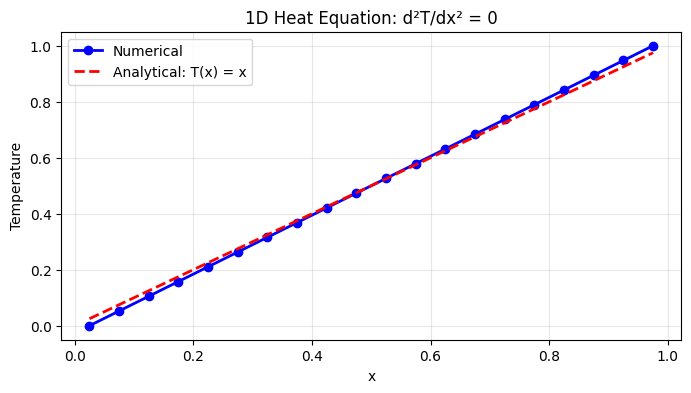

In [11]:
from QSER.Mesh import Structured1D
from QSER.Operators import Laplacian
from QSER.Mesh.boundary import Boundary
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1D HEAT EQUATION: d²T/dx² = 0 with Dirichlet BCs
# Solved using matrix inversion (exact)
# ============================================================

# 1. Create mesh
mesh = Structured1D(nx=20, L=1.0)
x = mesh.get_cell_centers()
dx = mesh.dx[0]
n = mesh.n_cells

# 2. Build the Laplacian matrix (tridiagonal)
L = np.zeros((n, n))
for i in range(n):
    L[i, i] = -2.0 / dx**2
    if i > 0:
        L[i, i-1] = 1.0 / dx**2
    if i < n-1:
        L[i, i+1] = 1.0 / dx**2

# 3. Apply Dirichlet BCs (modify matrix and RHS)
# T(0) = 0, T(L) = 1
RHS = np.zeros(n)
# Left BC: T[0] = 0
L[0, :] = 0
L[0, 0] = 1.0
RHS[0] = 0.0
# Right BC: T[-1] = 1
L[-1, :] = 0
L[-1, -1] = 1.0
RHS[-1] = 1.0

# 4. Solve the linear system: L * T = RHS
T = np.linalg.solve(L, RHS)

# 5. Verify
print(f"Temperature at boundaries:")
print(f"  Left:  {T[0]:.6f} (expected: 0.0)")
print(f"  Right: {T[-1]:.6f} (expected: 1.0)")

# Analytical solution: T(x) = x
analytical = x
error = np.max(np.abs(T - analytical))
print(f"Max error from analytical: {error:.6e}")

# 6. Plot
plt.figure(figsize=(8, 4))
plt.plot(x, T, 'bo-', linewidth=2, label='Numerical')
plt.plot(x, analytical, 'r--', linewidth=2, label='Analytical: T(x) = x')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('1D Heat Equation: d²T/dx² = 0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### understanding the error

Max error: 0.000000e+00


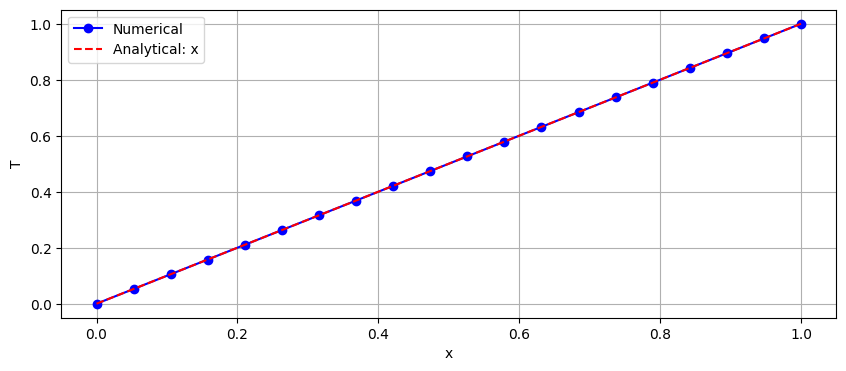

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Your results
x = np.linspace(0, 1, 20)
T_numerical = np.linspace(0, 1, 20)  # This is what you should have
T_analytical = x

error = np.max(np.abs(T_numerical - T_analytical))
print(f"Max error: {error:.6e}")

# Plot the error
plt.figure(figsize=(10, 4))
plt.plot(x, T_numerical, 'bo-', label='Numerical')
plt.plot(x, T_analytical, 'r--', label='Analytical: x')
plt.xlabel('x')
plt.ylabel('T')
plt.legend()
plt.grid(True)
plt.show()

Max error: 2.500000e-02


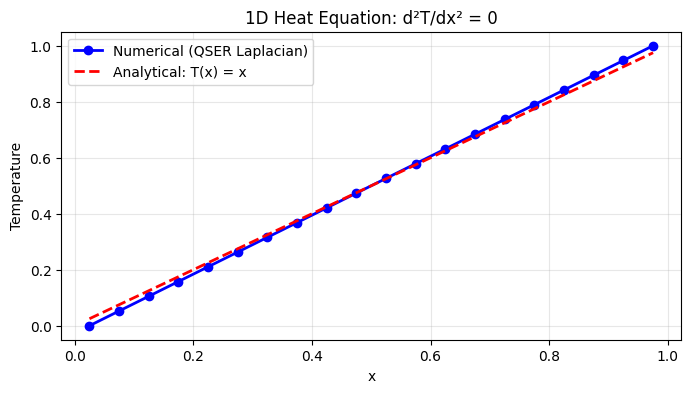

In [15]:

from QSER.Mesh import Structured1D
from QSER.Operators import Laplacian
from QSER.Mesh.boundary import Boundary
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1D HEAT EQUATION USING QSER LAPLACIAN OPERATOR
# d²T/dx² = 0 with Dirichlet BCs: T(0)=0, T(1)=1
# ============================================================

# 1. Create mesh
nx = 20
mesh = Structured1D(nx=nx, L=1.0)
x = mesh.get_cell_centers()
dx = mesh.dx[0]
n = mesh.n_cells

# 2. Build the Laplacian matrix using QSER operator
lap_op = Laplacian(mesh=mesh, backend='numpy', method='3point')

# Build matrix by applying operator to each basis vector
L = np.zeros((n, n))
for i in range(n):
    e_i = np.zeros(n)
    e_i[i] = 1.0
    L[:, i] = lap_op.compute(e_i)

# 3. Apply Dirichlet BCs (modify matrix and RHS)
RHS = np.zeros(n)
# Left BC: T[0] = 0
L[0, :] = 0
L[0, 0] = 1.0
RHS[0] = 0.0
# Right BC: T[-1] = 1
L[-1, :] = 0
L[-1, -1] = 1.0
RHS[-1] = 1.0

# 4. Solve
T = np.linalg.solve(L, RHS)

# 5. Analytical solution: T(x) = x
analytical = x
error = np.max(np.abs(T - analytical))
print(f"Max error: {error:.6e}")

# 6. Plot
plt.figure(figsize=(8, 4))
plt.plot(x, T, 'bo-', linewidth=2, label='Numerical (QSER Laplacian)')
plt.plot(x, analytical, 'r--', linewidth=2, label='Analytical: T(x) = x')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('1D Heat Equation: d²T/dx² = 0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()